In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

In [2]:
# Load IMDB dataset (top 10,000 words)
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [3]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print(X_train.shape)

(25000, 200)


In [4]:
model = Sequential()

model.add(Embedding(vocab_size, 128, input_length=max_len))
model.add(GRU(64))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)             │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gru (GRU)                         │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ ?                        │   0 (unbuilt) │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.9832 - loss: 0.0539 - val_accuracy: 0.8610 - val_loss: 0.5183
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.9906 - loss: 0.0301 - val_accuracy: 0.8610 - val_loss: 0.5512
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.9930 - loss: 0.0241 - val_accuracy: 0.8578 - val_loss: 0.5621
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.9895 - loss: 0.0302 - val_accuracy: 0.8526 - val_loss: 0.5900
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.9954 - loss: 0.0160 - val_accuracy: 0.8614 - val_loss: 0.7051


In [9]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8514 - loss: 0.7461
Test Accuracy: 0.851360023021698


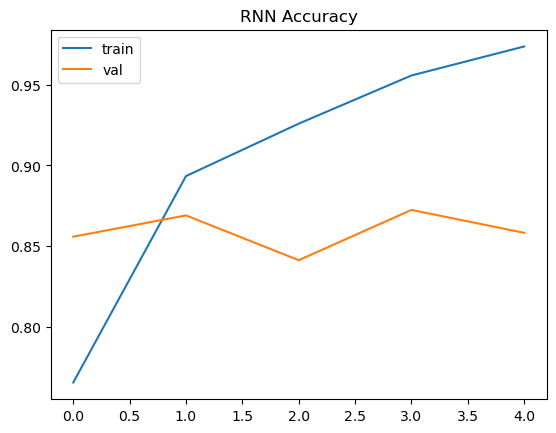

In [7]:
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.legend()
plt.title("RNN Accuracy")
plt.show()

In [ ]:
sample = X_test[0:1]
prediction = model.predict(sample)

print("Prediction:", prediction)
print("Class:", "Positive" if prediction > 0.5 else "Negative")